In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("All tools loaded successfully!")

All tools loaded successfully!


In [2]:
df = sns.load_dataset('titanic')
print("Dataset loaded!")
print("Number of passengers:", len(df))

Dataset loaded!
Number of passengers: 891


In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [5]:
# Fill missing ages with the average age
df['age'].fillna(df['age'].median(), inplace=True)

# Fill missing embarked with the most common value
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

# Remove the 'deck' column (77% of it is missing — not useful)
df.drop(columns=['deck'], inplace=True)

print("Data cleaned! Missing values now:")
print(df.isnull().sum())

Data cleaned! Missing values now:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64


In [6]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
survival_by_gender = df.groupby('sex')['survived'].mean() * 100
print("Survival Rate by Gender (%):")
print(survival_by_gender.round(1))

Survival Rate by Gender (%):
sex
female    74.2
male      18.9
Name: survived, dtype: float64


In [8]:
survival_by_class = df.groupby('pclass')['survived'].mean() * 100
print("Survival Rate by Class (%):")
print(survival_by_class.round(1))

Survival Rate by Class (%):
pclass
1    63.0
2    47.3
3    24.2
Name: survived, dtype: float64


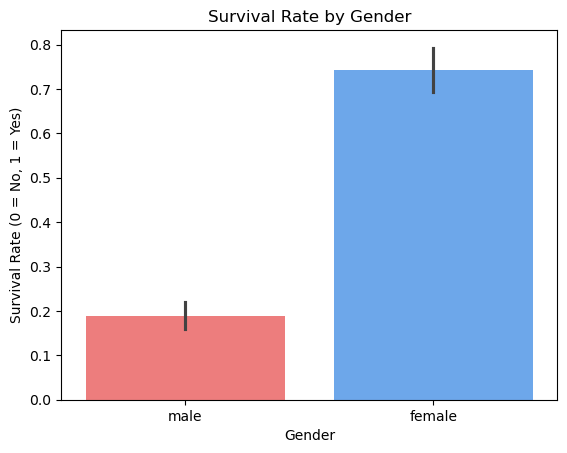

In [9]:
sns.barplot(data=df, x='sex', y='survived', palette=['#ff6b6b', '#58a6ff'])
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate (0 = No, 1 = Yes)')
plt.xlabel('Gender')
plt.show()

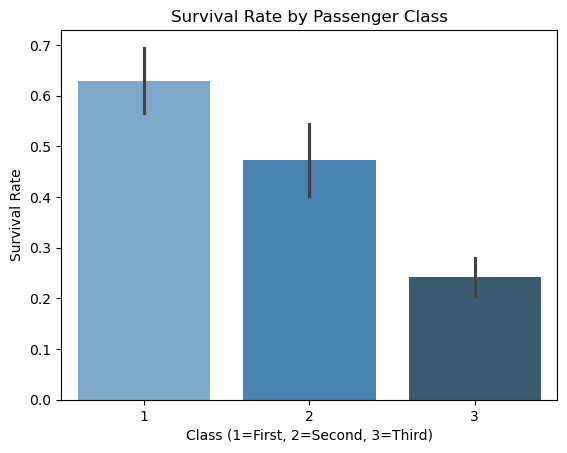

In [10]:
sns.barplot(data=df, x='pclass', y='survived', palette='Blues_d')
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.xlabel('Class (1=First, 2=Second, 3=Third)')
plt.show()

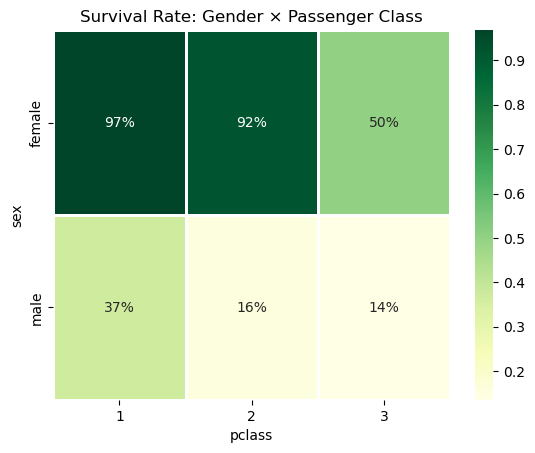

In [11]:
pivot = df.pivot_table('survived', index='sex', columns='pclass', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.0%', cmap='YlGn', linewidths=2)
plt.title('Survival Rate: Gender × Passenger Class')
plt.show()

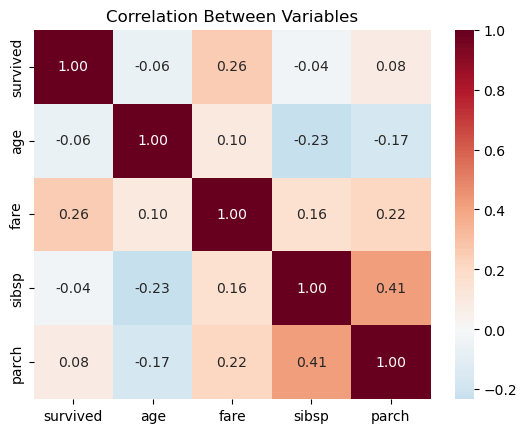

In [12]:
corr = df[['survived','age','fare','sibsp','parch']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Correlation Between Variables')
plt.show()

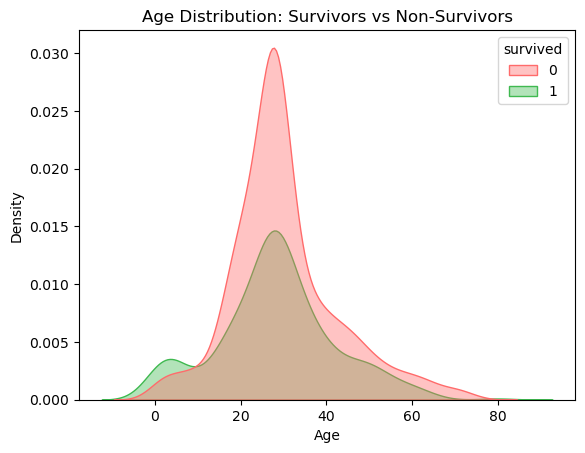

In [13]:
sns.kdeplot(data=df, x='age', hue='survived', fill=True, alpha=0.4,
            palette={0:'#ff6b6b', 1:'#3fb950'})
plt.title('Age Distribution: Survivors vs Non-Survivors')
plt.xlabel('Age')
plt.show()